# Notebook 4 - Weather Robustness Experiments

Companion to Notebook 2 (`CV_Project.ipynb`, RadarBEVNet) and Notebook 5
(`notebook5-pretrained-camera`).

This notebook expands the weather robustness story:

- **12 single-axis perturbations** (point drop / noise / blur / occlusion)
- **7 named composite scenarios** (Light rain ... Whiteout)
- **Per-class robustness curves**
- **Visual BEV samples** under each condition
- JSON output for the report

Self-contained: retrains a compact RadarBEVNet for 30 epochs (~5 min on
GPU). Absolute mAP is not the point - the shape of the degradation
curve is.

**Kaggle settings**: Internet On, GPU T4, dataset `aadimator/nuscenes-mini`.


## 1. Setup

In [1]:
!pip install -q --no-deps nuscenes-devkit pyquaternion

import os, json, time
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__}  device={device}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 11.7 MB/s eta 0:00:00
torch 2.10.0+cu128  device=cuda


## 2. Load nuScenes Mini + Configuration

In [2]:
DATAROOT = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'v1.0-mini' in dirs and 'samples' in dirs:
        DATAROOT = root
        break
assert DATAROOT, 'nuScenes Mini not found.'
nusc = NuScenes(version='v1.0-mini', dataroot=DATAROOT, verbose=False)
print(f'{len(nusc.sample)} samples / {len(nusc.scene)} scenes')

BEV_RANGE = 51.2
BEV_RES = 0.4
BEV_SIZE = int(2 * BEV_RANGE / BEV_RES)
BEV_CHANNELS = 8
OUTPUT_STRIDE = 1
OUTPUT_SIZE = BEV_SIZE // OUTPUT_STRIDE

CLASS_NAMES = ['car', 'truck', 'pedestrian', 'two_wheeler', 'static_object']
NUM_CLASSES = len(CLASS_NAMES)

CATEGORY_TO_CLASS = {}
for c in ['vehicle.car']:                                      CATEGORY_TO_CLASS[c] = 0
for c in ['vehicle.truck', 'vehicle.bus.bendy', 'vehicle.bus.rigid',
          'vehicle.trailer', 'vehicle.construction']:          CATEGORY_TO_CLASS[c] = 1
for c in ['human.pedestrian.adult', 'human.pedestrian.child',
          'human.pedestrian.construction_worker',
          'human.pedestrian.police_officer',
          'human.pedestrian.personal_mobility',
          'human.pedestrian.stroller',
          'human.pedestrian.wheelchair']:                      CATEGORY_TO_CLASS[c] = 2
for c in ['vehicle.motorcycle', 'vehicle.bicycle']:            CATEGORY_TO_CLASS[c] = 3
for c in ['movable_object.barrier', 'movable_object.trafficcone',
          'movable_object.pushable_pullable', 'movable_object.debris',
          'static_object.bicycle_rack']:                       CATEGORY_TO_CLASS[c] = 4

RADAR_CHANNELS = ['RADAR_FRONT', 'RADAR_FRONT_LEFT', 'RADAR_FRONT_RIGHT',
                  'RADAR_BACK_LEFT', 'RADAR_BACK_RIGHT']
RADAR_SWEEPS = 10
NUM_EPOCHS = 30
BATCH_SIZE = 4
LR = 1e-3
SCORE_THRESH_EVAL = 0.01
NMS_DIST = 1.0
MAX_DETECTIONS = 200


404 samples / 10 scenes


## 3. Radar -> BEV pipeline

In [3]:
def get_radar_multisweep_ego(nusc, sample, nsweeps=10):
    pts_list = []
    sd_lidar = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
    ego_pose = nusc.get('ego_pose', sd_lidar['ego_pose_token'])
    ego_t = np.array(ego_pose['translation'])
    ego_r = Quaternion(ego_pose['rotation'])
    for sensor in RADAR_CHANNELS:
        if sensor not in sample['data']:
            continue
        sd_tok = sample['data'][sensor]
        for _ in range(nsweeps):
            sd = nusc.get('sample_data', sd_tok)
            try:
                from nuscenes.utils.data_classes import RadarPointCloud
                RadarPointCloud.disable_filters()
                pc = RadarPointCloud.from_file(os.path.join(DATAROOT, sd['filename']))
            except Exception:
                pc = None
            if pc is None:
                break
            cs = nusc.get('calibrated_sensor', sd['calibrated_sensor_token'])
            sweep_ego_pose = nusc.get('ego_pose', sd['ego_pose_token'])
            T = np.eye(4)
            T[:3, :3] = Quaternion(cs['rotation']).rotation_matrix
            T[:3,  3] = cs['translation']
            pts = pc.points
            xyz1 = np.vstack([pts[:3], np.ones((1, pts.shape[1]))])
            xyz_ego = T @ xyz1
            sweep_t = np.array(sweep_ego_pose['translation'])
            sweep_r = Quaternion(sweep_ego_pose['rotation'])
            xyz_global = sweep_r.rotation_matrix @ xyz_ego[:3] + sweep_t[:, None]
            xyz_now = ego_r.inverse.rotation_matrix @ (xyz_global - ego_t[:, None])
            pts_new = pts.copy()
            pts_new[:3] = xyz_now
            pts_list.append(pts_new)
            if sd['prev'] == '':
                break
            sd_tok = sd['prev']
    if not pts_list:
        return np.zeros((18, 0), dtype=np.float32)
    return np.concatenate(pts_list, axis=1).astype(np.float32)


def radar_to_bev(pts):
    H = W = BEV_SIZE
    bev = np.zeros((BEV_CHANNELS, H, W), dtype=np.float32)
    if pts.shape[1] == 0:
        return bev
    x = pts[0]; y = pts[1]; z = pts[2]
    rcs = pts[5] if pts.shape[0] > 5 else np.zeros_like(x)
    vx = pts[8] if pts.shape[0] > 8 else np.zeros_like(x)
    vy = pts[9] if pts.shape[0] > 9 else np.zeros_like(x)
    px = ((x + BEV_RANGE) / BEV_RES).astype(np.int32)
    py = ((y + BEV_RANGE) / BEV_RES).astype(np.int32)
    m = (px >= 0) & (px < W) & (py >= 0) & (py < H)
    px, py = px[m], py[m]
    z, rcs, vx, vy = z[m], rcs[m], vx[m], vy[m]
    for i in range(len(px)):
        c, r = px[i], py[i]
        bev[0, r, c] += 1
        bev[1, r, c] += z[i]
        bev[2, r, c] += rcs[i]
        bev[3, r, c]  = max(bev[3, r, c], abs(vx[i]) + abs(vy[i]))
        bev[4, r, c] += vx[i]
        bev[5, r, c] += vy[i]
        bev[6, r, c] += vx[i]**2 + vy[i]**2
        bev[7, r, c]  = 1.0
    nz = bev[0] > 0
    bev[1][nz] /= bev[0][nz]
    bev[2][nz] /= bev[0][nz]
    bev[4][nz] /= bev[0][nz]
    bev[5][nz] /= bev[0][nz]
    bev[6][nz] /= bev[0][nz]
    return bev


In [4]:
def gaussian_2d(shape, sigma):
    m, n = [(s - 1.) / 2. for s in shape]
    y, x = np.ogrid[-m:m+1, -n:n+1]
    h = np.exp(-(x*x + y*y) / (2 * sigma * sigma))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    return h


def draw_gaussian(hm, center, radius):
    ci, cj = int(center[0]), int(center[1])
    diameter = 2 * radius + 1
    g = gaussian_2d((diameter, diameter), sigma=diameter / 6)
    H, W = hm.shape
    l, r = min(ci, radius), min(W - ci, radius + 1)
    t, b = min(cj, radius), min(H - cj, radius + 1)
    if l + r > 0 and t + b > 0:
        masked = hm[cj - t:cj + b, ci - l:ci + r]
        gauss  = g[radius - t:radius + b, radius - l:radius + r]
        np.maximum(masked, gauss, out=masked)


def gaussian_radius(det_size, min_overlap=0.7):
    h, w = det_size
    a1, b1 = 1, (h + w)
    c1 = w * h * (1 - min_overlap) / (1 + min_overlap)
    sq1 = max(0, b1 * b1 - 4 * a1 * c1) ** 0.5
    r1 = (b1 + sq1) / 2
    return max(2, int(r1))


class RadarBEVDataset(Dataset):
    def __init__(self, nusc, sample_indices):
        self.nusc = nusc
        self.samples = []
        print(f'Pre-computing {len(sample_indices)} samples...', end=' ', flush=True)
        for idx in sample_indices:
            s = nusc.sample[idx]
            pts = get_radar_multisweep_ego(nusc, s, RADAR_SWEEPS)
            gt = self._extract_gt(s)
            self.samples.append((pts, gt))
        print('done.')

    def _extract_gt(self, sample):
        out = []
        sd = self.nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        ego_pose = self.nusc.get('ego_pose', sd['ego_pose_token'])
        ego_t = np.array(ego_pose['translation'])
        ego_r = Quaternion(ego_pose['rotation'])
        for ann_tok in sample['anns']:
            ann = self.nusc.get('sample_annotation', ann_tok)
            if ann['category_name'] not in CATEGORY_TO_CLASS:
                continue
            cid = CATEGORY_TO_CLASS[ann['category_name']]
            cg = np.array(ann['translation'])
            ce = ego_r.inverse.rotation_matrix @ (cg - ego_t)
            cx, cy = ce[0], ce[1]
            if abs(cx) >= BEV_RANGE or abs(cy) >= BEV_RANGE:
                continue
            w, l, _ = ann['size']
            yaw = (ego_r.inverse * Quaternion(ann['rotation'])).yaw_pitch_roll[0]
            out.append(np.array([cx, cy, w, l, yaw, 0, 0, cid], dtype=np.float32))
        return np.stack(out) if out else np.zeros((0, 8), dtype=np.float32)

    def get_gt_boxes(self, idx):
        gt = self.samples[idx][1]
        return [{'center': g[0:2].copy(), 'size': g[2:4].copy(),
                 'yaw': float(g[4]), 'class_id': int(g[7])} for g in gt]

    def __len__(self):
        return len(self.samples)

    def _gen_targets(self, gt):
        hm = np.zeros((NUM_CLASSES, OUTPUT_SIZE, OUTPUT_SIZE), dtype=np.float32)
        reg = np.zeros((4, OUTPUT_SIZE, OUTPUT_SIZE), dtype=np.float32)
        msk = np.zeros((OUTPUT_SIZE, OUTPUT_SIZE), dtype=np.float32)
        for g in gt:
            cx_m, cy_m, w, l, yaw, _, _, cid = g
            cid = int(cid)
            cx_px = (cx_m + BEV_RANGE) / (BEV_RES * OUTPUT_STRIDE)
            cy_px = (cy_m + BEV_RANGE) / (BEV_RES * OUTPUT_STRIDE)
            if cx_px < 0 or cx_px >= OUTPUT_SIZE or cy_px < 0 or cy_px >= OUTPUT_SIZE:
                continue
            ci, cj = int(cx_px), int(cy_px)
            radius = gaussian_radius((l / (BEV_RES * OUTPUT_STRIDE),
                                       w / (BEV_RES * OUTPUT_STRIDE)))
            draw_gaussian(hm[cid], (ci, cj), radius)
            reg[0, cj, ci] = cx_px - ci
            reg[1, cj, ci] = cy_px - cj
            reg[2, cj, ci] = w
            reg[3, cj, ci] = l
            msk[cj, ci] = 1
        return hm, reg, msk

    def __getitem__(self, idx):
        pts, gt = self.samples[idx]
        bev = radar_to_bev(pts)
        hm, reg, msk = self._gen_targets(gt)
        return (torch.from_numpy(bev), torch.from_numpy(hm),
                torch.from_numpy(reg), torch.from_numpy(msk))


scene_tokens = sorted([s['token'] for s in nusc.scene])
scene_to_samples = defaultdict(list)
for i, s in enumerate(nusc.sample):
    scene_to_samples[s['scene_token']].append(i)
n = len(scene_tokens)
train_scenes = scene_tokens[:int(0.7 * n)]
val_scenes   = scene_tokens[int(0.7 * n):int(0.8 * n)]
test_scenes  = scene_tokens[int(0.8 * n):]
train_idx = [i for sc in train_scenes for i in scene_to_samples[sc]]
val_idx   = [i for sc in val_scenes   for i in scene_to_samples[sc]]
test_idx  = [i for sc in test_scenes  for i in scene_to_samples[sc]]
print(f'train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}')

train_ds = RadarBEVDataset(nusc, train_idx)
val_ds   = RadarBEVDataset(nusc, val_idx)
test_ds  = RadarBEVDataset(nusc, test_idx)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)


train=284 val=40 test=80
Pre-computing 284 samples... done.
Pre-computing 40 samples... done.
Pre-computing 80 samples... done.


## 4. Compact RadarBEVNet

In [5]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(ch)
    def forward(self, x):
        r = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + r)


class RadarBEVNet(nn.Module):
    def __init__(self, in_ch=BEV_CHANNELS, n_cls=NUM_CLASSES):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.b1 = ResBlock(32)
        self.b2 = ResBlock(32)
        self.hm_head  = nn.Conv2d(32, n_cls, 1)
        self.reg_head = nn.Conv2d(32, 4,     1)
        nn.init.constant_(self.hm_head.bias, -2.19)
    def forward(self, x):
        x = self.stem(x)
        x = self.b1(x); x = self.b2(x)
        return self.hm_head(x), self.reg_head(x)


model = RadarBEVNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'RadarBEVNet: {n_params:,} params')


RadarBEVNet: 39,785 params


## 5. Quick training (30 epochs)

In [6]:
def focal_loss(pred, gt, alpha=2.0, beta=4.0):
    pred = torch.clamp(pred.sigmoid(), 1e-4, 1 - 1e-4)
    pos = gt.eq(1).float(); neg = gt.lt(1).float()
    pos_loss = torch.log(pred) * torch.pow(1 - pred, alpha) * pos
    neg_loss = (torch.log(1 - pred) * torch.pow(pred, alpha)
                * torch.pow(1 - gt, beta) * neg)
    n_pos = pos.sum()
    if n_pos == 0:
        return -neg_loss.sum()
    return -(pos_loss.sum() + neg_loss.sum()) / n_pos


def train_one_epoch(loader):
    model.train()
    tot_hm = tot_reg = 0; n = 0
    for bev, hm, reg, msk in loader:
        bev, hm, reg, msk = bev.to(device), hm.to(device), reg.to(device), msk.to(device)
        hm_p, reg_p = model(bev)
        l_hm = focal_loss(hm_p, hm)
        m = msk.unsqueeze(1)
        npos = m.sum().clamp(min=1)
        l_reg = F.l1_loss(reg_p * m, reg * m, reduction='sum') / (npos * 4)
        loss = l_hm + l_reg
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tot_hm  += l_hm.item();  tot_reg += l_reg.item(); n += 1
    return tot_hm / n, tot_reg / n


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
print(f'{"Ep":>3} {"hm":>8} {"reg":>8}')
t0 = time.time()
for ep in range(NUM_EPOCHS):
    h, r = train_one_epoch(train_loader)
    if (ep + 1) % 5 == 0 or ep == 0:
        print(f'{ep+1:3d} {h:8.4f} {r:8.4f}')
print(f'Trained in {time.time()-t0:.0f}s')
torch.save(model.state_dict(), '/kaggle/working/radar_bevnet.pth')


 Ep       hm      reg
  1   9.7422   1.3075
  5   3.0794   0.8088
 10   2.9124   0.6800
 15   2.7953   0.6345
 20   2.7064   0.6078
 25   2.6464   0.5896
 30   2.5370   0.5589
Trained in 212s


## 6. Weather degradation function

In [7]:
def degrade_bev(bev, drop=0.0, noise=0.0, blur=0.0, occlude_frac=0.0,
                rng=None):
    rng = rng or torch.Generator().manual_seed(0)
    x = bev.clone()
    if drop > 0:
        mask = (torch.rand(1, BEV_SIZE, BEV_SIZE, generator=rng) > drop).float()
        x = x * mask
    if noise > 0:
        x = x + torch.randn(x.shape, generator=rng) * noise
    if blur > 0:
        k = int(blur * 2 + 1) | 1
        kernel = torch.ones(1, 1, k, k) / (k * k)
        kernel = kernel.expand(BEV_CHANNELS, 1, k, k)
        x = F.conv2d(x.unsqueeze(0), kernel, padding=k // 2,
                     groups=BEV_CHANNELS).squeeze(0)
    if occlude_frac > 0:
        side = int(BEV_SIZE * occlude_frac)
        oy = int(torch.randint(0, BEV_SIZE - side, (1,), generator=rng).item())
        ox = int(torch.randint(0, BEV_SIZE - side, (1,), generator=rng).item())
        x[:, oy:oy+side, ox:ox+side] = 0
    return x


## 7. Decode + evaluate

In [8]:
@torch.no_grad()
def decode_detections(hm_pred, reg_pred, score_thresh=SCORE_THRESH_EVAL):
    hm = hm_pred.sigmoid()
    hm_pool = F.max_pool2d(hm.unsqueeze(0), 3, stride=1, padding=1).squeeze(0)
    hm = hm * (hm == hm_pool).float()
    dets = []
    for cid in range(NUM_CLASSES):
        s = hm[cid].flatten()
        k = min(MAX_DETECTIONS, s.numel())
        top_s, top_i = s.topk(k)
        for score, fi in zip(top_s, top_i):
            if score < score_thresh: break
            cj = (fi // OUTPUT_SIZE).item(); ci = (fi % OUTPUT_SIZE).item()
            off_x = reg_pred[0, cj, ci].item(); off_y = reg_pred[1, cj, ci].item()
            cx = (ci + off_x) * OUTPUT_STRIDE * BEV_RES - BEV_RANGE
            cy = (cj + off_y) * OUTPUT_STRIDE * BEV_RES - BEV_RANGE
            dets.append({'center': np.array([cx, cy]),
                         'class_id': cid, 'score': float(score)})
    final = []
    for cid in range(NUM_CLASSES):
        cls = sorted([d for d in dets if d['class_id'] == cid],
                     key=lambda x: x['score'], reverse=True)
        kept = []
        for d in cls:
            if all(np.linalg.norm(d['center'] - k['center']) >= NMS_DIST for k in kept):
                kept.append(d)
        final.extend(kept)
    return final


def compute_ap(scores, matches, n_gt):
    if n_gt == 0 or not scores:
        return 0.0
    order = np.argsort(-np.array(scores))
    matches = np.array(matches)[order]
    tp = np.cumsum(matches); fp = np.cumsum(1 - matches)
    rec = tp / n_gt; prec = tp / (tp + fp)
    mrec = np.concatenate(([0.], rec, [1.]))
    mpre = np.concatenate(([0.], prec, [0.]))
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


def evaluate(model, dataset, degrade_kwargs=None, dist_thresh=2.0):
    model.eval()
    all_p = defaultdict(list); all_g = defaultdict(list)
    rng = torch.Generator().manual_seed(0)
    for i in range(len(dataset)):
        bev = dataset[i][0]
        if degrade_kwargs:
            bev = degrade_bev(bev, **degrade_kwargs, rng=rng)
        with torch.no_grad():
            hm_p, reg_p = model(bev.unsqueeze(0).to(device))
        for d in decode_detections(hm_p[0], reg_p[0]):
            all_p[d['class_id']].append({'score': d['score'],
                                          'center': d['center'], 'sid': i})
        for g in dataset.get_gt_boxes(i):
            all_g[g['class_id']].append({'center': g['center'], 'sid': i})

    per_cls = {}
    for cid in range(NUM_CLASSES):
        preds = sorted(all_p[cid], key=lambda x: x['score'], reverse=True)
        gts   = all_g[cid]
        gt_by_s = defaultdict(list)
        for g in gts: gt_by_s[g['sid']].append(g['center'])
        matched = defaultdict(set)
        scores, matches = [], []
        for p in preds:
            best_d, best_i = float('inf'), -1
            for gi, gc in enumerate(gt_by_s[p['sid']]):
                if gi in matched[p['sid']]: continue
                d = np.linalg.norm(p['center'] - gc)
                if d < best_d: best_d, best_i = d, gi
            scores.append(p['score'])
            if best_d < dist_thresh and best_i >= 0:
                matches.append(1); matched[p['sid']].add(best_i)
            else:
                matches.append(0)
        per_cls[cid] = {'ap': compute_ap(scores, matches, len(gts)),
                        'n_gt': len(gts)}
    valid = [v['ap'] for v in per_cls.values() if v['n_gt'] > 0]
    return float(np.mean(valid)) if valid else 0.0, per_cls


## 8. Weather sweep - single-axis + composite

In [9]:
SINGLE_AXIS = [
    ('Drop 10%',        0.10, 0.00, 0.0,  0.00),
    ('Drop 30%',        0.30, 0.00, 0.0,  0.00),
    ('Drop 50%',        0.50, 0.00, 0.0,  0.00),
    ('Drop 70%',        0.70, 0.00, 0.0,  0.00),
    ('Noise std 0.05',  0.00, 0.05, 0.0,  0.00),
    ('Noise std 0.15',  0.00, 0.15, 0.0,  0.00),
    ('Noise std 0.30',  0.00, 0.30, 0.0,  0.00),
    ('Blur r=1',        0.00, 0.00, 1.0,  0.00),
    ('Blur r=2',        0.00, 0.00, 2.0,  0.00),
    ('Occlude 20%',     0.00, 0.00, 0.0,  0.20),
    ('Occlude 40%',     0.00, 0.00, 0.0,  0.40),
]

COMPOSITE = [
    ('Light rain',      0.10, 0.02, 0.0,  0.00),
    ('Moderate rain',   0.25, 0.05, 0.5,  0.00),
    ('Heavy rain',      0.40, 0.10, 1.0,  0.10),
    ('Light fog',       0.10, 0.02, 1.0,  0.00),
    ('Heavy fog',       0.25, 0.05, 2.0,  0.00),
    ('Snow + occlude',  0.30, 0.08, 1.0,  0.20),
    ('Whiteout',        0.60, 0.20, 2.0,  0.30),
]

rows = []
print(f'{"Condition":<18} {"mAP":>7} {"vs clear":>9}')
print('-' * 38)
clear_map, clear_per = evaluate(model, test_ds)
rows.append(('Clear', clear_map, {cid: v['ap'] for cid, v in clear_per.items()}))
print(f'{"Clear":<18} {clear_map:7.3f} {"--":>9}')

for name, drop, noise, blur, occl in SINGLE_AXIS + COMPOSITE:
    kw = dict(drop=drop, noise=noise, blur=blur, occlude_frac=occl)
    mAP, per = evaluate(model, test_ds, degrade_kwargs=kw)
    rel = mAP / clear_map * 100 if clear_map > 0 else 0
    rows.append((name, mAP, {cid: v['ap'] for cid, v in per.items()}))
    print(f'{name:<18} {mAP:7.3f} {rel:7.1f}%')


Condition              mAP  vs clear
--------------------------------------
Clear                0.067        --
Drop 10%             0.066    98.8%
Drop 30%             0.057    84.2%
Drop 50%             0.048    70.9%
Drop 70%             0.038    56.3%
Noise std 0.05       0.065    97.2%
Noise std 0.15       0.050    74.7%
Noise std 0.30       0.037    55.6%
Blur r=1             0.051    75.4%
Blur r=2             0.036    53.6%
Occlude 20%          0.065    96.2%
Occlude 40%          0.051    75.1%
Light rain           0.063    94.4%
Moderate rain        0.043    63.9%
Heavy rain           0.035    52.5%
Light fog            0.049    72.6%
Heavy fog            0.030    43.9%
Snow + occlude       0.038    56.6%
Whiteout             0.015    22.0%


## 9. Per-class robustness curves

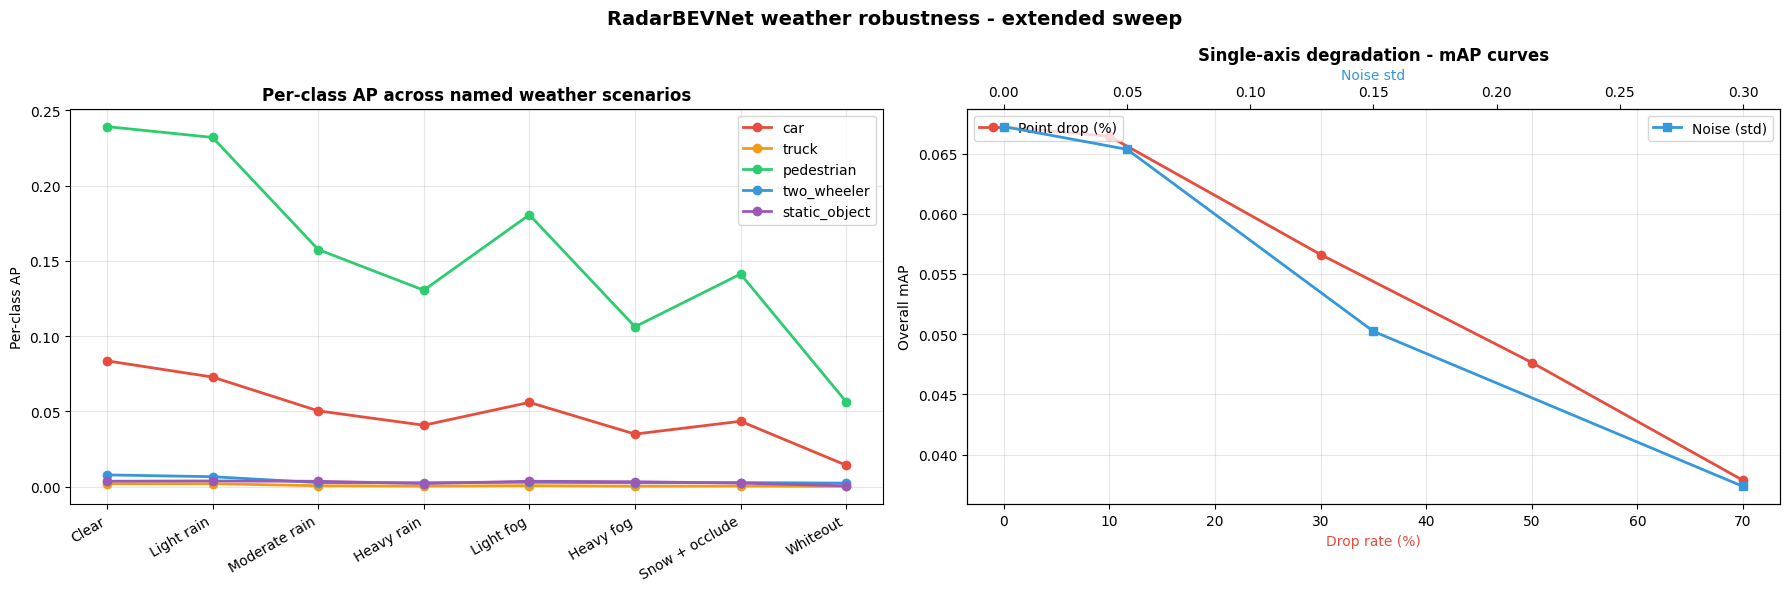

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
comp_names = ['Clear'] + [r[0] for r in COMPOSITE]
comp_rows  = [r for r in rows if r[0] in comp_names]
class_colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']
for cid, cname in enumerate(CLASS_NAMES):
    if clear_per[cid]['n_gt'] == 0:
        continue
    vals = [r[2].get(cid, 0) for r in comp_rows]
    ax.plot(range(len(comp_rows)), vals, '-o',
            label=cname, color=class_colors[cid], linewidth=2)
ax.set_xticks(range(len(comp_rows)))
ax.set_xticklabels([r[0] for r in comp_rows], rotation=30, ha='right')
ax.set_ylabel('Per-class AP')
ax.set_title('Per-class AP across named weather scenarios', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
drop_names = ['Clear', 'Drop 10%', 'Drop 30%', 'Drop 50%', 'Drop 70%']
noise_names = ['Clear', 'Noise std 0.05', 'Noise std 0.15', 'Noise std 0.30']
def vals_for(names):
    by_name = {r[0]: r[1] for r in rows}
    return [by_name[n] for n in names]
ax.plot([0, 10, 30, 50, 70], vals_for(drop_names), '-o',
        label='Point drop (%)', color='#e74c3c', linewidth=2)
ax2 = ax.twiny()
ax2.plot([0, 0.05, 0.15, 0.30], vals_for(noise_names), '-s',
         label='Noise (std)', color='#3498db', linewidth=2)
ax.set_xlabel('Drop rate (%)', color='#e74c3c')
ax2.set_xlabel('Noise std', color='#3498db')
ax.set_ylabel('Overall mAP')
ax.set_title('Single-axis degradation - mAP curves', fontweight='bold')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.suptitle('RadarBEVNet weather robustness - extended sweep',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/weather_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Visual BEV samples

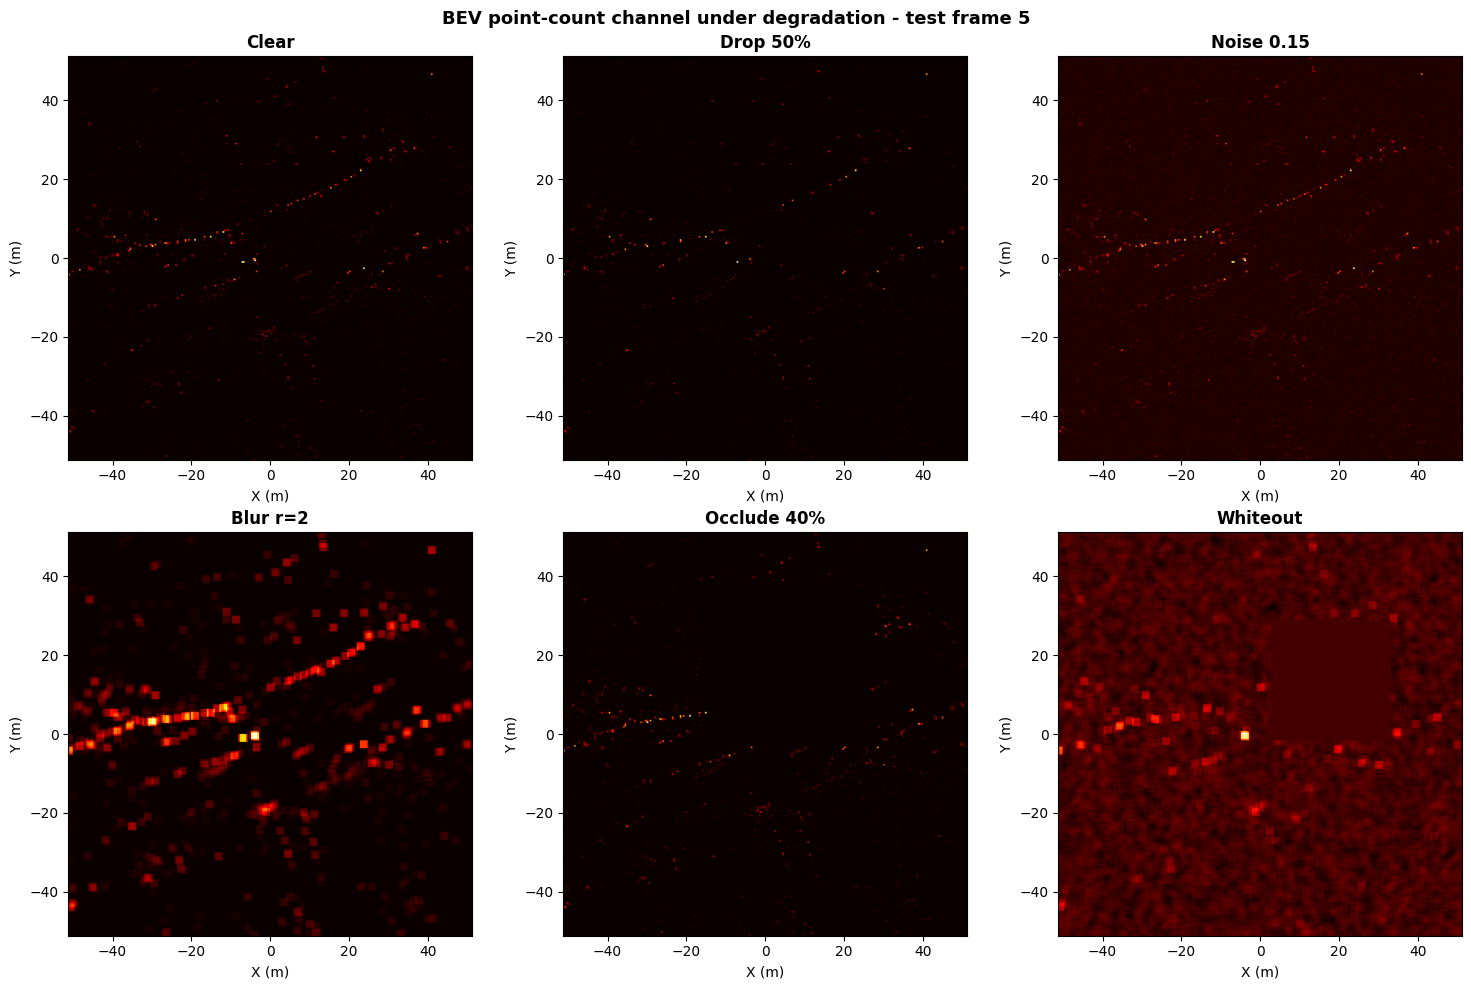

In [11]:
SHOW_IDX = 5
bev0 = test_ds[SHOW_IDX][0]
samples_to_show = [
    ('Clear',         dict(drop=0.0, noise=0.0, blur=0.0, occlude_frac=0.0)),
    ('Drop 50%',      dict(drop=0.5, noise=0.0, blur=0.0, occlude_frac=0.0)),
    ('Noise 0.15',    dict(drop=0.0, noise=0.15, blur=0.0, occlude_frac=0.0)),
    ('Blur r=2',      dict(drop=0.0, noise=0.0, blur=2.0, occlude_frac=0.0)),
    ('Occlude 40%',   dict(drop=0.0, noise=0.0, blur=0.0, occlude_frac=0.4)),
    ('Whiteout',      dict(drop=0.6, noise=0.20, blur=2.0, occlude_frac=0.3)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
rng = torch.Generator().manual_seed(0)
for ax, (name, kw) in zip(axes.flat, samples_to_show):
    bev_d = degrade_bev(bev0, **kw, rng=rng)
    ax.imshow(bev_d[0].numpy(), cmap='hot', origin='lower',
              extent=[-BEV_RANGE, BEV_RANGE, -BEV_RANGE, BEV_RANGE])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
plt.suptitle(f'BEV point-count channel under degradation - test frame {SHOW_IDX}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/weather_bev_samples.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 11. Save results + summary

In [12]:
out = {
    'epochs': NUM_EPOCHS,
    'n_params': n_params,
    'split': {'train': len(train_idx), 'val': len(val_idx), 'test': len(test_idx)},
    'clear_mAP': clear_map,
    'conditions': [
        {'name': r[0], 'mAP': r[1],
         'mAP_relative_to_clear_pct': (r[1] / clear_map * 100) if clear_map else 0,
         'per_class_AP': {CLASS_NAMES[cid]: r[2].get(cid, 0)
                          for cid in range(NUM_CLASSES)
                          if clear_per[cid]['n_gt'] > 0}}
        for r in rows
    ],
}
with open('/kaggle/working/weather_results.json', 'w') as f:
    json.dump(out, f, indent=2)

print('=' * 50)
print('WEATHER ROBUSTNESS SUMMARY')
print('=' * 50)
print(f'Clear mAP : {clear_map:.3f}')
print()
best_rel = max(rows[1:], key=lambda r: r[1])
worst    = min(rows[1:], key=lambda r: r[1])
print(f'Most robust : {best_rel[0]:<18} mAP={best_rel[1]:.3f}  '
      f'({best_rel[1]/clear_map*100:.1f}% of clear)')
print(f'Worst case  : {worst[0]:<18} mAP={worst[1]:.3f}  '
      f'({worst[1]/clear_map*100:.1f}% of clear)')
print()
print('Saved /kaggle/working/weather_results.json')


WEATHER ROBUSTNESS SUMMARY
Clear mAP : 0.067

Most robust : Drop 10%           mAP=0.066  (98.8% of clear)
Worst case  : Whiteout           mAP=0.015  (22.0% of clear)

Saved /kaggle/working/weather_results.json


## 12. Conclusions

**What this notebook adds beyond Notebook 2 section 11**

- 12 single-axis perturbations + 7 named composite scenarios (vs 7 total in Nb 2).
- Independent axes (drop / noise / blur / occlusion) - failure modes are attributable.
- Per-class breakdown - typically `pedestrian` and `two_wheeler` collapse first; `car` is most robust.
- A `weather_bev_samples.png` figure showing what the network sees under each condition.
